In [21]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC'];
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
%graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
database=['llnl.dat'];

# Variables 

These are the default values I wrote this script with.  The next cell you can change them.

XP=0.1 mol/L.  the initial amount of portlandite. should be a big number.

XC=1e-6 mol/L.  seed crystal amount (if zero then won't ever ppte because multiplication by zero).  1e-6 value from that paper from Australia.

kP=1e-5. just set as an arbitrary value.  need data to help figure out a reasonable value.

kC=1e-4. just set as an arbitrary value. need data to help figure out a  reasonable value.  makes sense to be faster than dissolution?

logPCO2=-3.5

kCO2=8.5e-7.  I picked a value that CO2 would go in slow enough. too fast and it just looks like the CO2 equilbirated model I made before.  (and show as a blue line in the graph below).

In [22]:
% variables

% amounts
%XP=0.5;  % there was almost 0.03 mol/L maximum Ca conc  at the beginning of the experiment.  (0.0226 mol/L from measured data (Below))
XC=1e-6; % need seed crystal of calcite.  batstone paper used 1e-6

mass=6; %g of cement. that is 15-25% by weight.
massCaOH2=mass*0.25; molport=massCaOH2/74.093
Vol=1; % volume of the bioreactor
XP=molport/Vol;

%equilib constants
%KspP=0.00000660693;  % from https://www.aqion.de/site/16 0.00000660693
%KspC=3.31131121e-9;  % Ksp for calcite
%KspC=10^-8.46249;
%KspC=4.7e-9;  % Ksp for calcite
%KspC=1e-14;
%Ksp=3.8e-9;
%logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room

% rate constants
kP=8e-1; %port dissoltuion
kC=1e-4; %calciate ppte
kCO2=5e-4; % gas transfer

% length of time to run the simulation
logtime=0.05:0.05:2.2; timetry=[0 10.^logtime];

%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00];

%pfit=[-3.37506	-2.50976	-4.22229];
%kP=10^pfit(1); kC=10^pfit(2); kCO2=10^pfit(3);


molport = 2.0245e-02


In [23]:
[Ca,pH,DIC,time]=CO2CaCO3CaOH2kineticmodel(XP,kP,kC,kCO2,timetry);

# play with the % occuring as CaOH2  if need more Ca that is a way to get it.

just occoured to me.  that CaOH2 should match the CO2 removal.

In [24]:
% data
%6 g cement small size

data=[...
%Sampling times (H)	pH A	DIC A (mmol/L)	Conductivity A (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.00	5.84	-0.1881	NaN	0.01702	-0.03982
0.10	11.96	0.7954	2419	4.96925	0.08025
2.00	11.99	1.0141	3390	3.80725	0.02971
24.00	11.3	0.7376	990	0.77950	0.22411
48.00	8.73	0.5577	496	1.92998	0.57714
72.00	8.15	1.1859	557	1.90958	1.15143
96.00	8.15	1.1150	554	1.83288	1.07643
144.00	8.13	1.0494	606	1.84188	1.02107
0.00	5.61	-0.2068 NaN		0.00676	-0.04007
0.10	12.04	0.8275	2608	5.04350	0.08868
2.00	12.15	0.6705	3430	6.72050	0.04064
24.00	11.34	2.0533	871	1.99965	0.26911
48.00	8.55	0.7090	494	1.95345	0.69750
72.00	8.12	1.1136	567	1.85363	1.13643
96.00	8.08	1.1206	538	1.81123	1.09679
144.00	8.10	0.9826	597	1.80800	1.04643
0.00	11.84	0.2322	NaN	0.04982	-0.00836
0.10	11.68	0.9485	2304.0	5.06950	0.09996
2.00	11.92	1.0993	5030	8.65500	0.05936
24.00	11.02	1.1953	1443	2.00810	0.31064
48.00	8.39	1.0427	563	2.04983	0.94643
72.00	8.19	1.1912	695	1.93080	1.13143
96.00	8.18	1.0197	701	1.94583	1.08000
144.00	8.13	0.9578	725	1.88958	0.97643
];

sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);



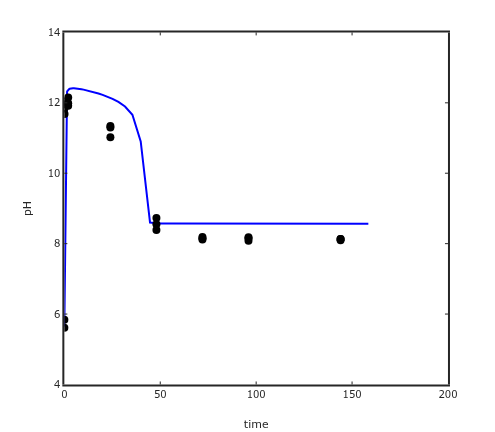

In [25]:

plot(time,pH,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

yi = interp1 (time, pH, sampletime);
%plot(sampletime,yi,'r.')

residual1=samplepH-yi;

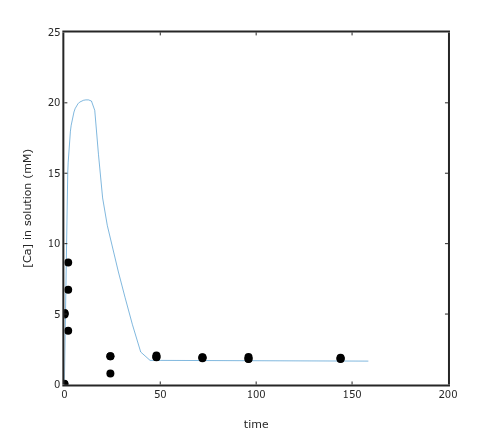

In [26]:
%plot(time(4:length(time)),Ca(4:length(time))); ylabel('[Ca] in solution'); xlabel('time')
plot(time(1:length(time)),1e3*Ca(1:length(time))); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleCa*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

yi = interp1 (time, Ca, sampletime);

%plot(sampletime,yi*1e3,'r.')

residual2=sampleCa*1e3-yi*1e3;

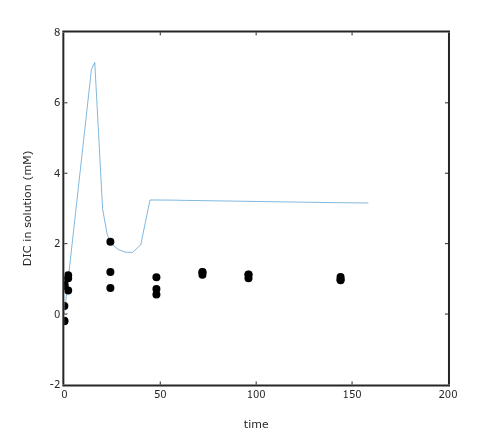

In [27]:
plot(time(1:length(time)),1e3*DIC(1:length(time))); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

yi = interp1 (time, DIC, sampletime);
%plot(sampletime,yi*1e3,'r.')

residual3=sampleDIC*1e3-yi*1e3;


In [28]:
Z=[residual1 residual2 residual3];
error=det(Z'*Z)

error = 3.9199e+06


In [29]:
%KspC=3.31131121e-9; KspC=10^-5.34117;
%ptst=log10([kP kC kCO2 KspC]);
ptst=log10([kP kC kCO2]);
detZtZ=CO2CaCO3CaOH2kineticmodelerror(ptst,XP,timetry,data)

detZtZ = 6.0500e+00


In [30]:
options = optimset('Display','iter','TolFun',1e-3,'TolX',1e-3);
%pbest=fminsearch(@(p) CO2CaCO3CaOH2kineticmodelerror(p,XP,timetry,data),ptst,options)